In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import scienceplots

import time
import math
from bisect import bisect_left
import os
import sys
import random
from functools import partial
from decimal import Decimal
from collections import Counter
import numpy as np
import scipy.io as sio
import pysindy as ps
from tqdm import trange

sys.path.insert(0, '../')
from utils import *
from solvel0 import solvel0, MIOSR
from best_subset import backward_refinement, brute_force_all_subsets, brute_force
from UBIC import *
from bayesian_model_evidence import log_evidence

from skimage.restoration import estimate_sigma
import bm3d
from kneed import KneeLocator

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn import covariance
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoLarsIC, lars_path, ElasticNet, ARDRegression
from abess import LinearRegression as AbessLinearRegression
from knockpy import KnockoffFilter, knockoff_stats, knockoffs
from knockpy.utilities import estimate_covariance
from scipy import stats
from statsmodels.stats.multitest import multipletests
from c2st.check import c2st # https://github.com/psteinb/c2st

from mbic import mbic, mbic2, ebic

from rdata import read_rds
from selective_inference import forward_stop_rule, sfs_si, stepwise_selective_inference, subset_fdr
import fpsample
from dppy.finite_dpps import FiniteDPP

from si4pipeline import (
                        construct_pipelines, 
                        extract_features, 
                        initialize_dataset, 
                        intersection, 
                        lasso, 
                        marginal_screening, 
                        stepwise_feature_selection, 
                        union, 
                        PipelineManager
                        )

from pymcdm import weights as obj_w
from compromise_programming import optimal_decision, compromise_programming, mcdm
from pyRankMCDA.algorithm import rank_aggregation

alibi is not installed in the environment.
pyDecision is not installed in the environment.


In [2]:
data_path = "../Datasets/"
data = sio.loadmat(os.path.join(data_path, "burgers.mat"))
u_clean = (data['usol']).real; u = u_clean.copy()
x = (data['x'][0]).real
t = (data['t'][:,0]).real
xt = np.array([x, t], dtype=object)
dt = t[1]-t[0]; dx = x[2]-x[1]

In [3]:
np.random.seed(0)
noise_type = "gaussian"
noise_lv = float(50)
print("Noise level:", noise_lv)
noise = 0.01*np.abs(noise_lv)*(u.std())*np.random.randn(u.shape[0],u.shape[1])
u = u + noise

Noise level: 50.0


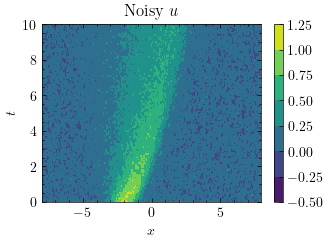

In [4]:
X, T = np.meshgrid(x, t)
with plt.style.context('science'):
    contour = plt.contourf(X, T, u.T, cmap='viridis')
    plt.colorbar(contour)
    plt.xlabel('$x$')
    plt.ylabel('$t$')
    plt.title('Noisy $u$')
    plt.show()

In [5]:
np.random.seed(0)
fake_noise = np.random.normal(loc=0.0, scale=estimate_sigma(u), size=u.shape)
sigmas = estimate_sigma(u+fake_noise)*np.arange(0.1, 2., 0.1)
est_sigma = sigmas[np.argmin([((u-bm3d.bm3d(u+fake_noise, sigma_psd=sigma, stage_arg=bm3d.BM3DStages.ALL_STAGES, blockmatches=(False, False)))**2).mean() \
                              for sigma in sigmas])]
u = bm3d.bm3d(u, sigma_psd=est_sigma, 
                  stage_arg=bm3d.BM3DStages.ALL_STAGES, 
                  blockmatches=(False, False))

### Weakident

In [6]:
# from weakident_python.weakindent_model import weak_ident

# # Ground truth
# true_coefficients = np.array([np.array([[2, 1, 0, -0.5], [1, 2, 0, 0.1]])])
# # Hyperparameters
# config = {'true_coefficients': true_coefficients, 
#           'max_dx': 6, 'max_poly': 6, 'use_cross_der': False, 'skip_x': 7, 'skip_t': 3, 'tau': 0.05}

# # Sparse regression
# np.random.seed(99)
# X_pre, y_pre, c_pred, dictionary_list, lhs_feature, rhs_feature = weak_ident(np.expand_dims(u, 0), xt, **config)
# feature_names = rhs_feature

### ps.WeakPDELibrary

In [7]:
n_poly = 6
n_derivatives = 6
n_weak = 2000
fit_intercept = False
include_bias = True
if include_bias:
    fit_intercept = False

### Cache (n_weak = 10000) ###
# X_pre = np.load("../Cache/X_pre_burgers_noise50.npy")
# y_pre = np.load("../Cache/y_pre_burgers_noise50.npy")
# u_pre = y_pre.copy()
# feature_names = np.load("../Cache/feature_names_burgers.npy")
# fsInf = read_rds("../R/R_data/fsInf_screening_burgers_noise50.rds")

function_library = ps.PolynomialLibrary(degree=n_poly, include_bias=False)

weak_lib = ps.WeakPDELibrary(
    function_library=function_library,
    derivative_order=n_derivatives,
    spatiotemporal_grid=np.asarray([*np.meshgrid(x, t)]).T,
    include_bias=include_bias,
    diff_kwargs={"is_uniform":True},
    K=n_weak
)

X_pre = np.array(weak_lib.fit_transform(np.expand_dims(u, -1)))
y_pre = weak_lib.convert_u_dot_integral(np.expand_dims(u, -1))
feature_names = np.array(weak_lib.get_feature_names())

# The system of linear equations
u_pre = y_pre.copy()
X_pre_top = StandardScaler(with_std=True).fit_transform(X_pre)
y_pre = StandardScaler(with_std=False).fit_transform(u_pre)

### How set AbessLinearRegression's s_max?

In [8]:
from scipy.special import comb
from scipy.stats import norm
from skglm import MCPRegression
# from skglm import MCPRegression, Lasso, ElasticNet # This will use Lasso and ElasticNet from skglm not from scikit learn
# statsmodels
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

def rebic(X, y, n_features, rss0=None, gamma=1, exact=True):
    n_samples, n_params = X.shape
    XT = X.T
    rss = (y.T@(np.eye(n_samples)-X@np.linalg.inv(XT@X)@XT)@y)[0][0]
    if rss0 is None:
        rss0 = (np.linalg.norm(y, ord=2)**2)/n_samples
    bic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples)
    rebic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples/(2*np.pi)) + (n_params+2)*np.log(rss0/rss)
    if exact:
        ebic = bic + 2*gamma*np.log(comb(n_features, n_params))
        rebic += 2*gamma*np.log(comb(n_features, n_params))
    else:
        ebic = bic + 2*n_params*gamma*np.log(n_features)
        rebic += 2*n_params*gamma*np.log(n_features)
    return rebic, ebic, bic
    
def rebic_scorer(est, X, y, gamma=1, robust=False, exact=True, sic=False):
    n_samples = len(y)
    pred = est.predict(X)
    if y.shape != pred.shape:
        y = y.reshape(pred.shape)
    rss = np.sum((y - est.predict(X)) ** 2)
    n_params = np.count_nonzero(est.coef_) + (1 if est.fit_intercept else 0)
    n_features = len(est.coef_) + (1 if est.fit_intercept else 0)
    bic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples)
    if sic:
        return bic    
    rss0 = (np.linalg.norm(y, ord=2)**2)/n_samples
    if exact:
        ebic = bic + 2*gamma*np.log(comb(n_features, n_params))
        rebic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples/(2*np.pi)) + (n_params+2)*np.log(rss0/rss) + 2*gamma*np.log(comb(n_features, n_params))
    else:
        ebic = bic + 2*n_params*gamma*np.log(n_features)
        rebic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples/(2*np.pi)) + (n_params+2)*np.log(rss0/rss) + 2*n_params*gamma*np.log(n_features)
    if not robust:
        return ebic
    return rebic

def penalized_mse_scorer(est, X, y, l0_penalty=None):
    pred = est.predict(X)
    if y.shape != pred.shape:
        y = y.reshape(pred.shape)
    rss = np.linalg.norm(y - est.predict(X), 2)
    n_params = np.count_nonzero(est.coef_) + (1 if est.fit_intercept else 0)
    if l0_penalty is None:
        l0_penalty = 1e-3 * np.linalg.cond(X)
    return rss + l0_penalty * n_params

def lambda_max(X, y):
    """
    Compute lambda_max for MCP (same as Lasso): max abs correlation / n.
    Assumes X standardized, y centered.
    """
    n, p = X.shape
    return np.max(np.abs(X.T @ y)) / n

# c in (0, 1]
def plugin_lasso_lambda(X, y, c=0.25, t=np.finfo(np.float32).tiny, homoskedastic=True, lambda_max=False):
    n, p = X.shape
    assert n == len(y)

    lambda_value = 4*np.sqrt((t**2 + 2 * np.log(p)) / n)

    if homoskedastic:
        ols_result = sm.OLS(y, X).fit()
        # var = y.T.dot(y) / n
        var = np.sum(ols_result.resid**2) / ols_result.df_resid
        sigma = np.sqrt(var)
        lambda_value = sigma * lambda_value

    lambda_value = c * float(lambda_value)
    if lambda_max:
        return min(lambda_value, lambda_max(X, y))
    return lambda_value

cv = 3
l1_c = 0
s_max_mse = 16
s_max_ic = 16
# penalized_mse_scorer = partial(penalized_mse_scorer, l0_penalty=None)
penalized_mse_scorer = partial(penalized_mse_scorer, l0_penalty=10**sci_format(np.linalg.lstsq(X_pre_top, y_pre, rcond=None)[1][0])[1])
rebic_scorer = partial(rebic_scorer, gamma=1, robust=False, sic=False)

if l1_c > 0:
    # meta_lr = Lasso(alpha=plugin_lasso_lambda(X_pre_top, y_pre, c=l1_c, fit_intercept=fit_intercept).fit(X_pre_top, y_pre.ravel())
    meta_lr = ElasticNet(alpha=plugin_lasso_lambda(X_pre_top, y_pre, c=l1_c), l1_ratio=0.5, fit_intercept=fit_intercept).fit(X_pre_top, y_pre.ravel())
    # meta_lr = MCPRegression(alpha=plugin_lasso_lambda(X_pre_top, y_pre, c=l1_c), gamma=3, fit_intercept=fit_intercept).fit(X_pre_top, y_pre.ravel())
    s_max = min(s_max, np.count_nonzero(meta_lr.coef_))
else:
    min_mse_score = np.inf
    min_ic_score = np.inf
    for l1_c in (0.5, 0.75, 1):
        meta_lr = ElasticNet(alpha=plugin_lasso_lambda(X_pre_top, y_pre, c=l1_c), l1_ratio=0.5, fit_intercept=fit_intercept)
        avg_mse_score = np.mean(cross_val_score(clone(meta_lr), X_pre_top, y_pre, cv=cv, scoring=penalized_mse_scorer))
        avg_ic_score = np.mean(cross_val_score(clone(meta_lr), X_pre_top, y_pre, cv=cv, scoring=rebic_scorer))
        s_max = np.count_nonzero(meta_lr.fit(X_pre_top, y_pre.ravel()).coef_)
        if avg_mse_score < min_mse_score:
            min_mse_score = avg_mse_score
            s_max_mse = min(s_max_mse, s_max)
        if avg_ic_score < min_ic_score:
            min_ic_score = avg_ic_score
            s_max_ic = min(s_max_ic, s_max)
        # print(l1_c, avg_mse_score, avg_ic_score)

s_max = min(s_max_mse, s_max_ic)

### Knockoff filtering

In [9]:
from hidimstat.knockoffs import model_x_knockoff_bootstrap_quantile, model_x_knockoff_bootstrap_e_value
from sklearn.utils import resample
from abess import LinearRegression as AbessLinearRegression
from knockpy import KnockoffFilter, knockoff_stats, knockoffs
from knockpy.utilities import estimate_covariance
from scipy import stats
from statsmodels.stats.multitest import multipletests
from c2st.check import c2st # https://github.com/psteinb/c2st

print("s_max:", s_max)
importance_type = 'swap'
ksampler = 'gaussian'
kgen_method = 'ci' # ci, maxent, mvr
lr = AbessLinearRegression(path_type='gs', s_max=s_max, fit_intercept=fit_intercept, cv=cv, screening_size=0)
if importance_type.lower() == 'shap':
    kfilter = KnockoffFilter(ksampler=ksampler, fstat=knockoff_stats.ShapStatistic(model=lr), 
                             knockoff_kwargs={'method':kgen_method})
elif importance_type.lower() == 'lasso':
    kfilter = KnockoffFilter(ksampler=ksampler, fstat='lasso', knockoff_kwargs={'method':kgen_method})
else:
    kfilter = KnockoffFilter(ksampler=ksampler, fstat=knockoff_stats.FeatureStatistic(model=lr), 
                             knockoff_kwargs={'method':kgen_method}, fstat_kwargs={'feature_importance':importance_type})

fdr = 1/3 # 1/5, 1/4, 1/3, 1/2
shrinkage = "ledoitwolf" # "ledoitwolf", "MLE"
shrinkage_tol = 1e-2
rejections = []
test_scores = []
thresholds = []
np.random.seed(1234)
for _ in trange(50):
    np.random.seed(_)
    # rejection = kfilter.forward(X=X_pre_top, y=y_pre.flatten(), fdr=fdr, shrinkage=shrinkage, recycle_up_to=0.5, tol=shrinkage_tol)
    rejection = kfilter.forward(X=X_pre_top, y=(y_pre/y_pre.std()).flatten(), fdr=fdr, shrinkage=shrinkage, recycle_up_to=0.5, tol=shrinkage_tol)
    rejection = sorted(set(np.where(rejection == 1)[0]))
    if len(rejection) > 0:
        rejections.append(rejection)
        test_scores.append(kfilter.W)
        thresholds.append(kfilter.threshold)
# For knockoffs aggregation
test_scores = np.array(test_scores)
thresholds = np.array(thresholds)

s_max: 8


100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 13.45it/s]


### Knockoffs aggregation

In [10]:
from knockoffs_aggregation import fdr_selection

# aggregated_ko_selection, _, _ = model_x_knockoff_bootstrap_quantile(test_scores, 
#                                                                     fdr=fdr, gamma=0.5, 
#                                                                     fdr_control='bhq')
# aggregated_ko_selection = np.where(fdr_selection(test_scores, fdr=fdr, adaptive_aggregation=True) > 0)[0]
# print("model_x_knockoff_bootstrap_quantile:")
# print(feature_names[aggregated_ko_selection])

# TODO: Calculate 1-FDR
# ShapStatistic: 1/4 -> [] | 1/3 -> ['x0_11' 'x0_1111' 'x0x0_1' 'x0^6x0_1'] | 1/2 -> ['x0_11' 'x0_1111' 'x0x0_1' 'x0^6x0_1' 'x0x0_1111' 'x0^2x0_11111']
# swap: 1/3 -> ['x0_11' 'x0_1111' 'x0x0_1' 'x0^6x0_1'] | 1/2 -> ['x0_11' 'x0_1111' 'x0x0_1' 'x0^6x0_1' 'x0x0_1111' 'x0^2x0_11111']
# swapint: ['x0_11' 'x0_1111' 'x0x0_1' 'x0^6x0_1']
eval_selection = []
while True:
    eval_selection, _, _ = model_x_knockoff_bootstrap_e_value(test_scores, thresholds, fdr=fdr)
    eval_selection = np.where(fdr_selection(test_scores, fdr=fdr, fdr_control="ebh", evalues=True) > 0)[0]
    if len(eval_selection) > 0:
        break
    else:
        fdr += 1e-3
print("model_x_knockoff_bootstrap_e_value:")
print(feature_names[eval_selection])
print(fdr)

model_x_knockoff_bootstrap_e_value:
['x0_11' 'x0_1111' 'x0x0_1' 'x0^6x0_1']
0.3333333333333333


In [11]:
def shap_feature_elimination(X, y, threshold=0.01):
    threshold = min(threshold, 1)
    keep = np.arange(X.shape[1])
    remove = []
    while True:
        shap_values = shap_linear_importance(X[:, keep], y, scale=False, full=True)
        abs_shap = np.abs(shap_values).mean(axis=0)
        abs_shap_pct = (abs_shap / abs_shap.sum())
        keep_mask = abs_shap_pct >= threshold
        if keep_mask.all():
            break
        remove.extend(keep[~keep_mask])
        keep = keep[keep_mask]
    return keep.tolist(), remove

rejections = np.array(eval_selection)
assert len(rejections) > 0

shap_values = shap_linear_importance(X_pre_top[:, rejections], y_pre, scale=False, full=True)
abs_shap = abs(shap_values).mean(axis=0)
abs_shap /= 0.01*abs_shap.sum()
_ = np.argsort(abs_shap)[::-1]
_ = _[abs_shap[_] > 1][:s_max]

rejections = rejections[_]
shap_values = shap_values[:, _]
X_pre_top = X_pre_top[:, rejections]
del _
feature_names[rejections]

array(['x0x0_1', 'x0_11', 'x0_1111', 'x0^6x0_1'], dtype='<U13')

In [12]:
keep, remove = shap_feature_elimination(X_pre_top, y_pre)
X_pre_top = X_pre_top[:, keep]
rejections = rejections[keep]
shap_values = shap_values[:, keep]

alpha = 0.1
classifer_threshold = 0.5
X_non_null = X_pre_top.copy()
shap_non_null = shap_values.copy()
delete_seq = []
n_updates = len(rejections) # 1, len(rejections)
while n_updates > 0:
    stop = True
    Sigma, invSigma = estimate_covariance(X_non_null, shrinkage_tol, shrinkage=shrinkage)
    sv = abs(shap_non_null).mean(axis=0); sv /= sv.sum()
    for j in range(X_non_null.shape[-1]-1, max(bisect_left(np.cumsum(sv), 0.9)-1, 0)-1, -1):
    # for j in range(X_non_null.shape[-1]-1, X_non_null.shape[-1]//2, -1):
        classifier_confidences = []
        for _ in trange(50):
            Xk = knockoffs.GaussianSampler(X_non_null, Sigma=Sigma, invSigma=invSigma, 
                                           method='ci').sample_knockoffs()
            Xn = X_non_null.copy()
            Xn[:, j] = Xk[:, j]
            
            swap_shap_values = shap_linear_importance(Xn, y_pre, scale=False, full=True)
            classifier_confidences.append(c2st(shap_non_null[:, j:j+1], swap_shap_values[:, j:j+1], 
                                               clf=linear_model.LogisticRegression(fit_intercept=fit_intercept)))
    
        classifier_confidences = np.array(classifier_confidences)
        # print("binary classifier's acc:", classifier_confidences.mean())
        pv = stats.wilcoxon(classifier_confidences-classifer_threshold, alternative='greater').pvalue
        
        if not pv < alpha:
            delete_seq.append(j)
            X_non_null = np.delete(X_non_null, j, axis=-1)

            keep, remove = shap_feature_elimination(X_non_null, y_pre)
            X_non_null = X_non_null[:, keep]
            if len(remove) > 0:
                delete_seq.extend(remove)
            print(delete_seq)
            
            shap_non_null = shap_linear_importance(X_non_null, y_pre, scale=False, full=True)
            stop = False
            n_updates -= 1
            break
            
    if stop: break

for j in delete_seq:
    rejections = np.delete(rejections, j)
    X_pre_top = np.delete(X_pre_top, j, axis=-1)
del X_non_null, shap_non_null, delete_seq, keep, remove, Xk, Xn
feature_names[rejections]

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 29.40it/s]


[3]


100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 28.26it/s]


array(['x0x0_1', 'x0_11', 'x0_1111'], dtype='<U13')

### Best-subset Regression

In [13]:
X_pre = StandardScaler(with_std=True).fit_transform(X_pre)
rejections = np.union1d(np.where(abs(brute_force(X_pre, y_pre, support_size=len(rejections))) > 0)[0], 
                        rejections)
X_pre_top = X_pre[:, rejections]

# best_subsets = brute_force_all_subsets(normalize_lp(X_pre_top)[0], y_pre)[1]
best_subsets = brute_force_all_subsets(X_pre_top, y_pre)[1]
b_bics = np.array([sm.OLS(y_pre, X_pre_top[:, bs]).fit().bic for bs in best_subsets])
best_subsets = [best_subsets[_] for _ in decreasing_values_indices(b_bics)]
b_bics = b_bics[decreasing_values_indices(b_bics)]

100%|██████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 6550.19it/s]


### Conformal predictions

In [14]:
# import warnings; warnings.filterwarnings("ignore")
from mapie.utils import train_conformalize_test_split, train_test_split
from mapie.regression import SplitConformalRegressor, JackknifeAfterBootstrapRegressor, CrossConformalRegressor
from mapie.metrics.regression import regression_coverage_score, regression_mean_width_score, regression_mwi_score
from sklearn.metrics import mean_pinball_loss
import uncertainty_toolbox as uct
from model_diagnostics.scoring import decompose, SquaredError, PinballLoss
from icomp import icomp_ifim_complexity, ricomp_m_complexity, ricomp_s_complexity, ricomp_mm_complexity

# Convert (lower, upper) to (mu, sigma)
def interval_to_mu_sigma(lower, upper, confidence_level=0.9):
    mu = (lower + upper) / 2
    z = norm.ppf((1 + confidence_level) / 2)
    sigma = (upper - lower) / (2 * z)
    return mu, sigma

# pinball losses
def pinball_triplet(y_true, y_pred, lower, upper, quantile=0.5, confidence_level=0.9):
    return [mean_pinball_loss(y_true, lower, alpha=1-confidence_level), 
            mean_pinball_loss(y_true, y_pred, alpha=quantile), 
            mean_pinball_loss(y_true, upper, alpha=confidence_level)]

cp_method = 'split' # split, jack, cross
threshold_lambda = 1e6 # 1e4, 1e5, 1e6
conformity_score = "absolute" # "absolute", "residual_normalized" (only valid for SplitConformalRegressor), "gamma"
n_iters = 600
coverage = 0.90
quantile_level = 0.5
ridge_alpha = 1e-5

F = []
coverage_probabilities = []
prediction_widths = []
for bs in best_subsets:
    cp = 0; width = 0
    com = 0; pb = 0
    mc = 0; dc = 0;
    pde_uct = 0; error_bar = 0
    for _ in trange(n_iters):
        ridge = Ridge(fit_intercept=fit_intercept, alpha=ridge_alpha)

        if cp_method == 'split':
            ## Split conformal regression ##
            (X_train, X_conformalize, X_test, y_train, y_conformalize, y_test) = train_conformalize_test_split(
                X_pre_top[:, bs], y_pre.ravel(), 
                train_size=0.6, conformalize_size=0.2, test_size=0.2, 
                random_state=_
            )
            mapie_regressor = SplitConformalRegressor(estimator=ridge, confidence_level=coverage, conformity_score=conformity_score, prefit=False)
            mapie_regressor.fit(X_train, y_train).conformalize(X_conformalize, y_conformalize)
        else:
            (X_train, X_test, y_train, y_test) = train_test_split(
                X_pre_top[:, bs], y_pre.ravel(), 
                test_size=0.2, 
                random_state=_
            )
            if cp_method == 'jack':
                ## JackknifeAfterBootstrapRegressor ##
                mapie_regressor = JackknifeAfterBootstrapRegressor(estimator=regressor, confidence_level=coverage, conformity_score="absolute", random_state=_)
            elif cp_method == 'cross':
                ## CrossConformalRegressor ##
                mapie_regressor = CrossConformalRegressor(estimator=regressor, confidence_level=coverage, conformity_score="absolute", cv=cv, random_state=_)
            else:
                assert StopIteration
            mapie_regressor.fit_conformalize(X_train, y_train)

        ard = ARDRegression(fit_intercept=fit_intercept, threshold_lambda=threshold_lambda, max_iter=1000)
        # ard.fit(X_pre_top[:, bs], y_pre.ravel())
        ard.fit(X_train, y_train)
        ard_coef = ard.coef_[abs(ard.coef_) > 0]
        
        ## Predict interval ##
        y_pred, y_pred_interval = mapie_regressor.predict_interval(X_test)
        lower, upper = y_pred_interval[:, 0, 0], y_pred_interval[:, 1, 0]
        y_pred_mu, y_pred_sigma = interval_to_mu_sigma(lower, upper, coverage)
        
        ## metrices ##
        # com += icomp_ifim_complexity(X_train, y_train)
        com += ricomp_mm_complexity(X_train, y_train, update_scale=False) # ricomp_m_complexity, ricomp_s_complexity, ricomp_mm_complexity
        cp += regression_coverage_score(y_test, y_pred_interval)[0]
        width += regression_mean_width_score(y_pred_interval)[0]
        pde_uct += np.linalg.norm(np.sqrt(np.diag(ard.sigma_)), 1)/np.linalg.norm(ard_coef, 1) # PDE uncertainty
        error_bar += np.sum(np.diag(ard.sigma_)/ard_coef**2)
        # uct.metrics_scoring_rule.nll_gaussian(y_pred_mu, y_pred_sigma, y_test, scaled=True)
        # uct.metrics_scoring_rule.check_score(y_test, y_pred_interval, confidence_level=coverage)
        # uct.metrics_scoring_rule.crps_gaussian(y_test, y_pred_interval, confidence_level=coverage)
        # regression_mwi_score(y_test, y_pred_interval, confidence_level=coverage)
        pb += np.mean(pinball_triplet(y_test, y_pred, lower, upper, quantile=quantile_level, confidence_level=coverage))
        miscalibration, discrimination = np.array(decompose(y_test, y_pred, 
                                                            # scoring_function=SquaredError(), 
                                                            scoring_function=PinballLoss(level=quantile_level), 
                                                            functional="quantile")[['miscalibration', 'discrimination']])[0]
        # mc += uct.metrics_calibration.mean_absolute_calibration_error(y_pred_mu, y_pred_sigma, y_test)
        mc += miscalibration
        dc += discrimination

    cp /= n_iters; width /= n_iters
    coverage_probabilities.append(cp)
    prediction_widths.append(width)
    F.append(np.array([com, pb, 
                       pde_uct, error_bar, 
                       mc, dc])/n_iters)
    print("Support size:", len(bs))
    print(cp, width)

F = np.array(F)
(model_complexities, pinball_losses, 
 pde_uncertainties, error_bars, 
 miscalibration, discrimination) = F.T
pde_uncertainties /= pde_uncertainties.min()
complexities = np.array([len(bs) for bs in best_subsets])
error_bars /= error_bars.min()
F = F[~np.isnan(F).any(axis=-1)]

100%|████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:08<00:00, 73.19it/s]


Support size: 1
0.8990708333333332 0.013102136762145377


100%|████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:08<00:00, 68.73it/s]


Support size: 2
0.9006833333333336 0.008083710638923942


100%|████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:09<00:00, 61.62it/s]

Support size: 3
0.9007916666666667 0.007496240692808001


In [15]:
if len(b_bics) > 2:
    selected_alternatives = np.sort(np.argsort(b_bics)[:5])
    # weighting options: 'entropy_weights', 'angle_weights', 'gini_weights', 'variance_weights'
    # selected_criteria = [0, 1, 2, 4]; update_weights = True; weighting_method = 'variance_weights'
    # selected_criteria = range(len(F.T)); update_weights = False; weighting_method = 'variance_weights'
    selected_criteria = [0, 1, 2, 4]; update_weights = False; weighting_method = 'variance_weights'
    
    # preprocessing / normalization
    rel0 = lambda _: _ - _.min()
    rel1 = lambda _: _ / _.min()
    nF = F.copy()
    # complexity
    nF[:, 0] += complexities
    nF[:, 0] = rel0(nF[:, 0])
    # pinball_losses
    nF[:, 1] = rel0(np.log(nF[:, 1]))
    # pde_uncertainty, error_bars
    nF[:, 2] = np.log(rel1(nF[:, 2]))
    nF[:, 3] = np.log(rel1(nF[:, 3]))
    # miscalibration, discrimination
    nF[:, 4] = rel0(np.log(nF[:, 4]))
    nF[:, 5] = rel0(np.log(nF[:, 5]))
    
    # types (-1 for min / +1 for max) and obj_w
    types = np.array([-1, -1, -1, -1, -1, +1])
    nF = nF[:, selected_criteria]
    types = types[selected_criteria]
    obj_weights = getattr(obj_w, weighting_method)(nF, types=types)
    
    # recursive mcdm
    mcdm_iters = 5
    min_alternatives = 2
    keep_from = 0
    filtered_F = nF[selected_alternatives].copy()
    filtered_complexities = complexities[selected_alternatives].copy()
    while len(filtered_F) > min_alternatives and mcdm_iters > 0:
        if update_weights:
            obj_weights = getattr(obj_w, weighting_method)(filtered_F, types=types)
        
        print("Weights:", 100*obj_weights)
        print("Normalized alternatives"); print(filtered_F)
        print()
        filtered_complexities = filtered_complexities[keep_from:]
        ranks, prefs = mcdm(filtered_F, obj_weights, types)
        
        # Rank aggregation ('bd'  -> Borda Method | 'rrf' -> Reciprocal Rank Fusion | 'sc'  -> Schulze Method)
        ranks = np.array(ranks).T.astype(np.int32)
        ranks = rank_aggregation(ranks).run_methods(methods=['bd', 'rrf', 'sc']).values
        ranks = (np.argsort(ranks, axis=0) + 1).T
        borda_counts = np.sum([len(_)+1-_ for _ in ranks], axis=0)
        keep_from = min(np.where(borda_counts == borda_counts.max())[0])
        filtered_F = filtered_F[keep_from:]
    
        mcdm_iters -= 1
    
    prefs = np.array(prefs).T
    print('>>> Filtered alternatives:', filtered_F)
else:
    print(np.argmin(b_bics))

Weights: [22.11428238 26.6482783  25.14760316 26.08983617]
Normalized alternatives
[[0.         0.62714395 0.38528117 0.65643431]
 [1.0165872  0.06303499 0.         0.        ]
 [2.36145838 0.         0.31947269 0.08213756]]

>>> Filtered alternatives: [[1.0165872  0.06303499 0.         0.        ]
 [2.36145838 0.         0.31947269 0.08213756]]


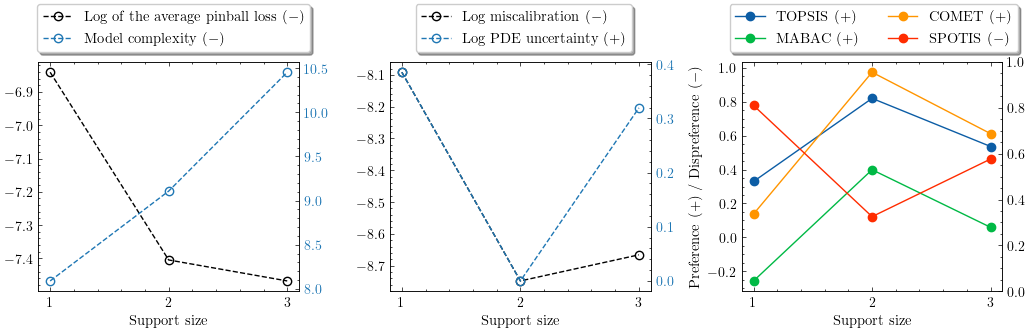

In [16]:
with plt.style.context('science'):
    figsize = 3.5; ncols = 3
    fig, (ax1l, ax2l, ax3l) = plt.subplots(figsize=(figsize*ncols, ncols), ncols=ncols)
    
    # R2 scores vs Prediction width
    ax1r = ax1l.twinx()
    ax1l.plot(complexities, np.log(pinball_losses), '--o', c='black', markerfacecolor='none', label='Log of the average pinball loss ($-$)')
    ax1l.set_xticks(complexities)
    ax1l.set_xlabel('Support size', fontsize=10.5)
    ax1r.plot(complexities, complexities+model_complexities, '--o', c='tab:blue', markerfacecolor='none', label='Model complexity ($-$)')
    ax1r.tick_params(labelcolor='tab:blue')
    
    # Miscalibration vs Discrimination
    ax2r = ax2l.twinx()
    ax2l.plot(complexities, np.log(miscalibration), '--o', c='black', markerfacecolor='none', label='Log miscalibration ($-$)')
    ax2l.set_xticks(complexities)
    ax2l.set_xlabel('Support size', fontsize=10.5)
    ax2r.plot(complexities, np.log(pde_uncertainties), '--o', c='tab:blue', markerfacecolor='none', label='Log PDE uncertainty ($+$)')
    ax2r.tick_params(labelcolor='tab:blue')

    # pde_uncertainty, error_bars
    ax3r = ax3l.twinx()
    ax3l.plot(filtered_complexities, prefs, '-o', label=["TOPSIS ($+$)", "MABAC ($+$)", "COMET ($+$)", "SPOTIS ($-$)"])
    ax3l.set_xticks(filtered_complexities)
    ax3l.set_ylabel("Preference ($+$) / Dispreference ($-$)", fontsize=10.5)
    ax3l.set_xlabel("Support size", fontsize=10.5)
    
    for _, axlr in enumerate([[ax1l, ax1r], [ax2l, ax2r], [ax3l, ax3r]]):
        handles = []
        labels = []
        for ax in axlr:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(1/ncols*_+0.175, 1.15), ncol=len(labels)//2, fontsize=10.5,
                   frameon=True, fancybox=True, shadow=True)
    
    fig.tight_layout()
    plt.show()

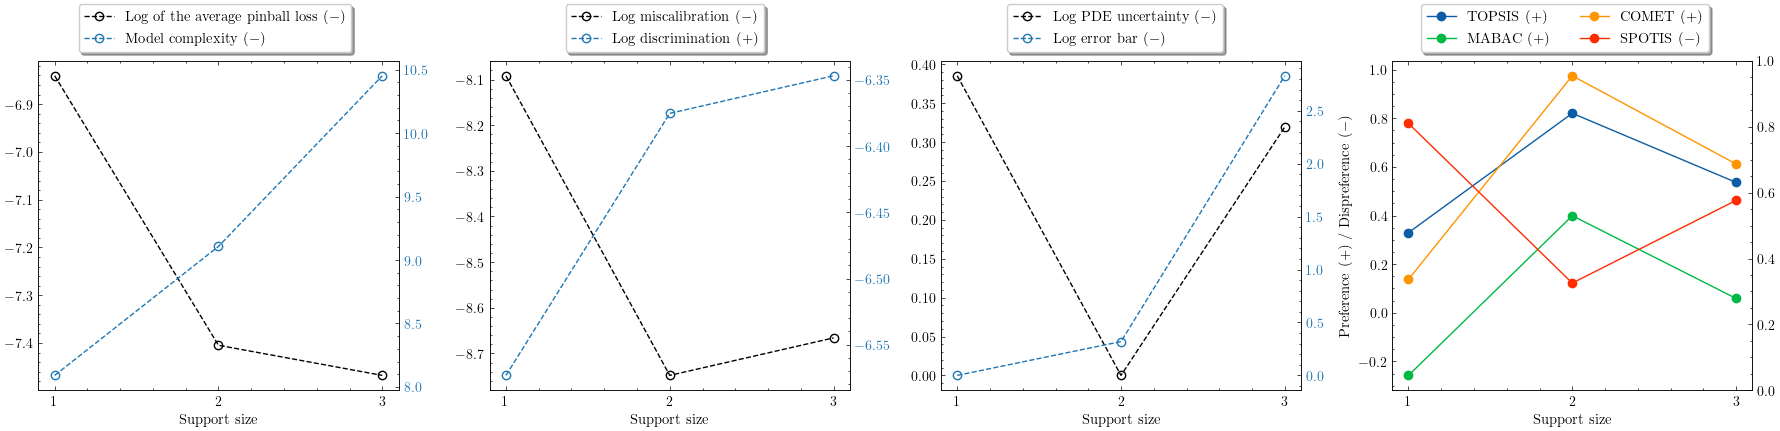

In [17]:
with plt.style.context('science'):
    figsize = 4.5; ncols = 4
    fig, (ax1l, ax2l, ax3l, ax4l) = plt.subplots(figsize=(figsize*ncols, ncols), ncols=ncols)
    
    # R2 scores vs Prediction width
    ax1r = ax1l.twinx()
    ax1l.plot(complexities, np.log(pinball_losses), '--o', c='black', markerfacecolor='none', label='Log of the average pinball loss ($-$)')
    ax1l.set_xticks(complexities)
    ax1l.set_xlabel('Support size', fontsize=10.5)
    ax1r.plot(complexities, complexities+model_complexities, '--o', c='tab:blue', markerfacecolor='none', label='Model complexity ($-$)')
    ax1r.tick_params(labelcolor='tab:blue')
    
    # Miscalibration vs Discrimination
    ax2r = ax2l.twinx()
    ax2l.plot(complexities, np.log(miscalibration), '--o', c='black', markerfacecolor='none', label='Log miscalibration ($-$)')
    ax2l.set_xticks(complexities)
    ax2l.set_xlabel('Support size', fontsize=10.5)
    ax2r.plot(complexities, np.log(discrimination), '--o', c='tab:blue', markerfacecolor='none', label='Log discrimination ($+$)')
    ax2r.tick_params(labelcolor='tab:blue')

    # Winkler interval score vs Continuous ranked probability score
    ax3r = ax3l.twinx()
    ax3l.plot(complexities, np.log(pde_uncertainties), '--o', c='black', markerfacecolor='none', label='Log PDE uncertainty ($-$)')
    ax3l.set_xticks(complexities)
    ax3l.set_xlabel('Support size', fontsize=10.5)
    ax3r.plot(complexities, np.log(error_bars), '--o', c='tab:blue', markerfacecolor='none', label='Log error bar ($-$)')
    ax3r.tick_params(labelcolor='tab:blue')

    # pde_uncertainty, error_bars
    ax4r = ax4l.twinx()
    ax4l.plot(filtered_complexities, prefs, '-o', label=["TOPSIS ($+$)", "MABAC ($+$)", "COMET ($+$)", "SPOTIS ($-$)"])
    ax4l.set_xticks(filtered_complexities)
    ax4l.set_ylabel("Preference ($+$) / Dispreference ($-$)", fontsize=10.5)
    ax4l.set_xlabel("Support size", fontsize=10.5)
    
    for _, axlr in enumerate([[ax1l, ax1r], [ax2l, ax2r], [ax3l, ax3r], [ax4l, ax4r]]):
        handles = []
        labels = []
        for ax in axlr:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(1/ncols*_+0.125, 1.11), ncol=len(labels)//2, fontsize=10.5,
                   frameon=True, fancybox=True, shadow=True)
    
    fig.tight_layout()
    plt.show()

### Compromise programming

In [18]:
optimal_decision(best_subsets, (X_pre_top, y_pre), rank_aggregation_methods=['bd', 'rrf', 'sc'], verbose=True)

Generate alternatives: [(2,) (0, 2) (0, 1, 2)]
[[1.         0.05100725 1.47198467]
 [2.         0.01436911 1.        ]
 [3.         0.0120725  1.37385463]]

Recursive MCDM
Weights: [0.27120415 0.6881844  0.04061146]
[(1, 3)] [[1.         0.05100725 1.47198467]
 [2.         0.01436911 1.        ]
 [3.         0.0120725  1.37385463]]


([(1, 3)],
 array([[1.        , 0.05100725, 1.47198467],
        [2.        , 0.01436911, 1.        ]]))

In [19]:
compromise_programming(best_subsets, (X_pre_top, y_pre), criterion="bic")

[[-1.54700250e+04  1.00000000e+00]
 [-1.79961977e+04  2.00000000e+00]
 [-1.83369001e+04  3.00000000e+00]] [(1, 3)]


(array([[0.05100725, 1.        ],
        [0.01436911, 2.        ],
        [0.01207249, 3.        ]]),
 [[(1, 3)]],
 [[array([0.28268429, 0.79690982, 0.71731571]),
   array([-0.24066923,  0.25005777,  0.19396218]),
   array([0.25      , 0.78586921, 0.75      ]),
   array([0.71731571, 0.2265887 , 0.28268429])]])

In [20]:
compromise_programming(best_subsets, (X_pre_top, y_pre), criterion="bme")

[[-3.37825497e+03  1.00000000e+00]
 [-3.38401057e+03  2.00000000e+00]
 [-3.38147876e+03  3.00000000e+00]] [(1, 3)]


(array([[0.05100725, 1.        ],
        [0.01436911, 2.        ],
        [0.01207249, 3.        ]]),
 [[(1, 3)]],
 [[array([0.28268429, 0.83799408, 0.48675491]),
   array([-0.17320479,  0.40276877, -0.0541107 ]),
   array([0.25     , 0.875    , 0.4200853]),
   array([0.71731571, 0.14134215, 0.59822162])]])

### UBIC

In [21]:
tau = 3
verbose = True
# scale = 1 <- generalized UBIC
scale = np.log(len(y_pre))
per = 75 # 80

post_means, b_bics, b_uns = baye_uncertainties(best_subsets, (X_pre_top, y_pre), 
                                               u_type='cv1', take_sqrt=True, 
                                               ridge_lambda=0, 
                                               threshold=0)
# b_uns = ard_uns # USE ard_uns INSTEAD
predictions = X_pre_top@post_means
print(b_bics)
print(b_uns)
b_bics = np.array(b_bics)
max_complexity = len(b_bics)
complexities = np.arange(max_complexity)+1
d_complexities = complexities[decreasing_values_indices(b_bics)]
d_bics = b_bics[decreasing_values_indices(b_bics)]
slopes = np.diff(b_bics)/(np.diff(complexities)*b_bics[:-1])
try:
    thres = np.percentile(np.abs(np.diff(d_bics)/(np.diff(d_complexities)*d_bics[:-1])), per)
    # None / Round / Ceil / Floor: Decided by researchers to automate the model selection process
    thres = np.round(sci_format(thres)[0])*10**sci_format(thres)[1]
except IndexError:
    thres = 1/40
min_thres = 1/40
thres = max(thres, min_thres)
print("threshold:", thres)

lower_bounds = []
for k, efi in enumerate(best_subsets):
    # assert len(efi) == np.count_nonzero(post_means[:, k:k+1])
    com = len(efi)
    lower_bound = 2*np.abs(log_like_value(predictions[:, k:k+1], y_pre))-np.log(len(y_pre))*com
    lower_bounds.append(lower_bound)

last_lam = np.log10(max(lower_bounds/(b_uns*scale)))
print("max_lam:", last_lam)
delta = last_lam/tau
now_lam = last_lam-delta
last_ubic = UBIC(b_bics, b_uns, len(y_pre), hyp=10**last_lam, scale=scale)
last_bc = np.argmin(last_ubic)
bc_seq = [last_bc]
while now_lam >= 0:
    now_ubic = UBIC(b_bics, b_uns, len(y_pre), hyp=10**now_lam, scale=scale)
    now_bc = np.argmin(now_ubic)
    
    diff_com = now_bc-last_bc
    diff_bic = b_bics[now_bc]-b_bics[last_bc]
    imp = np.nan
    if diff_com != 0:
        imp = abs(diff_bic/(b_bics[last_bc]*diff_com))
    
    if verbose:
        print(min(last_bc, now_bc), '<--->', max(last_bc, now_bc), 
              np.nan_to_num(imp, nan=np.inf))
    
    if (diff_com > 0 and (diff_bic > 0 or imp < thres)) or \
        (diff_com < 0 and diff_bic > 0 and imp > thres):
        break
    
    last_lam = now_lam
    now_lam = round(last_lam-delta, 8)
    last_ubic = now_ubic
    last_bc = now_bc
    if last_bc not in bc_seq:
        bc_seq.append(last_bc)

# best_bc = knee(range(len(last_ubic)), last_ubic, 0.95, 'linear', direction='decreasing')
best_bc = knee_finder(last_ubic)
if best_bc == 0 and last_bc != 0 and b_bics[last_bc] < b_bics[0] and \
                                    abs((b_bics[last_bc]-b_bics[0])/(b_bics[0]*last_bc)) > thres:
    best_bc = knee(range(1, len(last_ubic)), last_ubic[1:], 0.95, 'linear')
if best_bc is None:
    best_bc = knee_finder(last_ubic)
    
last_lam = round(last_lam, 8)
last_lam, last_ubic, last_bc, best_bc

[-15470.024985286609, -17996.19766799774, -18336.90011534934]
[1.47236296 1.         1.37362541]
threshold: 0.1
max_lam: 3.37431559537933
1 <---> 1 inf
1 <---> 2 0.018931912931666857


(2.24954373, array([-13481.99114341, -16645.96413451, -16482.18502222]), 1, 1)

### Log evidence

In [22]:
improvement_threshold = thres # 0.1
dvi = set(decreasing_values_indices(b_bics))
sel = 0; sel_v = 0
imp_track = {}
for v in np.arange(0.05, 0.55, 0.05):
    new_sel = np.argmax([log_evidence(X_pre_top[:, bs], y_pre, v=v) for bs in best_subsets])
    
    if new_sel > np.argmin(b_bics):
        break
        
    if new_sel > sel:
        if knee_finder(b_bics) <= new_sel and new_sel in dvi:
            imp = abs((b_bics[new_sel]-b_bics[sel])/(complexities[new_sel]-complexities[sel])/b_bics[sel])
            imp_track[v] = imp
            if imp > improvement_threshold:
                sel = new_sel
                sel_v = v
    else:
        sel_v = v

assert len(imp_track) > 0
sel_v = [sel_v for sel_v, _ in imp_track.items() if _ == max(imp_track.values())][-1] if sel_v == 0 else sel_v
relative_log_evidences = np.array([log_evidence(X_pre_top[:, bs], y_pre, v=sel_v) for bs in best_subsets])
relative_log_evidences -= relative_log_evidences.min()
sel_v, np.argmax(relative_log_evidences)

(0.5, 1)

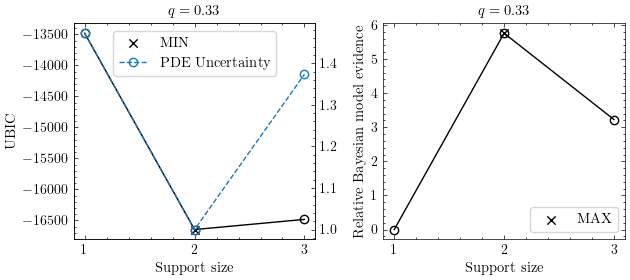

In [23]:
with plt.style.context('science'):
    fig, (ax1l, ax2) = plt.subplots(1, 2, figsize=(6.5, 3))
    
    # UBIC and PDE Uncertainty
    ax1r = ax1l.twinx()
    ax1l.plot(complexities, last_ubic, '-o', c='black', markerfacecolor='none')
    ax1l.scatter(complexities[best_bc], last_ubic[best_bc], marker='x', c='black', label='MIN')
    ax1r.plot(complexities, b_uns, '--o', c='tab:blue', markerfacecolor='none', label='PDE Uncertainty')
    ax1l.set_xticks(complexities)
    ax1l.set_xlabel('Support size', fontsize=10.5)
    ax1l.set_ylabel('UBIC', fontsize=10.5)
    ax1l.set_title(f'$q = {round(fdr, 2)}$', fontsize=10.5)
    handles = []
    labels = []
    for ax in [ax1l, ax1r]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    ax1l.legend(handles, labels, loc='upper center', fontsize=10.5,frameon=True)
    
    # Relative Bayesian model evidence
    ax2.plot(complexities, relative_log_evidences, '-o', c='black', markerfacecolor='none')
    ax2.scatter(complexities[np.argmax(relative_log_evidences)], relative_log_evidences[np.argmax(relative_log_evidences)], 
                marker='x', c='black', label='MAX')
    ax2.set_xticks(complexities)
    ax2.set_xlabel('Support size', fontsize=10.5)
    ax2.set_ylabel('Relative Bayesian model evidence', fontsize=10.5)
    ax2.set_title(f'$q = {round(fdr, 2)}$', fontsize=10.5)
    ax2.legend(loc='lower right', fontsize=10.5, frameon=True)
    
    plt.tight_layout()
    plt.show()

### EBIC

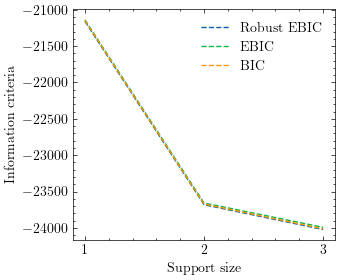

In [24]:
rebics, ebics, b_bics = np.array([rebic(X_pre_top[:, bs], y_pre, n_features=len(feature_names)) \
                                  for bs in best_subsets]).T
with plt.style.context('science'):
    fig, ax = plt.subplots(figsize=(3.6, 3))
    ax.plot(complexities, rebics, '--', label='Robust EBIC')
    ax.plot(complexities, ebics, '--', label='EBIC')
    ax.plot(complexities, b_bics, '--', label='BIC')
    ax.set_xticks(complexities)
    ax.set_xlabel('Support size', fontsize=10)
    ax.set_ylabel('Information criteria', fontsize=10)
    plt.legend(fontsize=10)
    plt.show()

### Selective inference

In [25]:
# Assume that mbics is a decreasing sequence
complexities = np.array([len(_) for _ in best_subsets])

if len(best_subsets) <= 2:
    knee = complexities.max()
else:
    ebics = []
    mbics = []
    for _ in best_subsets:
        loglik = log_like_value(X_pre_top[:, _]@np.linalg.lstsq(X_pre_top[:, _], y_pre, rcond=None)[0], 
                                y_pre)
        ebics.append(ebic(loglik, len(_), len(y_pre), X_pre_top.shape[-1], const=0))
        mbics.append(mbic(loglik, len(_), len(y_pre), X_pre_top.shape[-1], const=2))
    ebics = np.array(ebics)
    mbics = np.array(mbics)

    if np.alltrue(np.array(mbics) >= np.array([max(mbics)+_*(min(mbics)-max(mbics))/(np.argmin(mbics)-np.argmax(mbics)) for _ in range(len(best_subsets))])):
        knee = complexities.max()
    else:    
        decreasing_indices = np.array(mbics) <= np.array([max(mbics)+_*(min(mbics)-max(mbics))/(np.argmin(mbics)-np.argmax(mbics)) for _ in range(len(best_subsets))])
        knee = knee_finder(mbics[decreasing_indices])
        knee = (complexities[decreasing_indices])[knee]
    
knee

2

In [26]:
np.random.seed(0); random.seed(0)
n_samples = min(int(250*knee), len(y_pre))
false_discovery_control_method = None
fdr_data = []
for bs in best_subsets:
    fdrs = []
    for _ in range(len(y_pre)//n_samples):
        X_test = X_pre_top[:, bs]
        y_test = y_pre.ravel()
        
        np.random.seed(random.randint(0, 100))
        # sample_indices = sorted(set([np.random.randint(len(y_pre)) for _ in range(n_samples)]))
        sample_indices = fpsample.bucket_fps_kdline_sampling(X_test, n_samples=n_samples, h=3) # Farthest Point Sampling (FPS) is better!!!
        X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
        # FPS + k-DPP
        DPP = FiniteDPP('likelihood', **{'L': X_test.dot(X_test.T)})
        DPP.flush_samples()
        for _ in range(n_samples//(len(bs))):
            DPP.sample_exact_k_dpp(size=len(bs))
        sample_indices = np.unique(np.ravel(DPP.list_of_samples))
        X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
        
        manager = stepwise_selective_inference(support_size=X_test.shape[1])
        M, p_list = manager.inference(X_test, y_test, np.std(y_test))
        if false_discovery_control_method is not None:
            p_list = stats.false_discovery_control(p_list, method=false_discovery_control_method)
        
        fdrs.append(subset_fdr(p_list))
        
    fdrs = np.array(fdrs)
    if fdrs.mean() < 1:
        print(len(bs), fdrs.mean())
        fdr_data.append(fdrs)
        
fdr_data = np.array(fdr_data)

1 0.0
2 7.495781773848513e-11
3 0.04729971962884364


In [27]:
from sklearn.cluster import AffinityPropagation, KMeans
print(AffinityPropagation().fit(fdr_data).labels_)
print(KMeans(n_clusters=2).fit(fdr_data).labels_)

[0 0 1]
[0 0 1]


In [28]:
np.random.seed(0); random.seed(0)
n_samples = min(int(250*knee), len(y_pre))
false_discovery_control_method = 'by'
fdr_data = []
for bs in best_subsets:
    fdrs = []
    for _ in range(len(y_pre)//n_samples):
        X_test = X_pre_top[:, bs]
        y_test = y_pre.ravel()
        
        np.random.seed(random.randint(0, 100))
        # sample_indices = sorted(set([np.random.randint(len(y_pre)) for _ in range(n_samples)]))
        sample_indices = fpsample.bucket_fps_kdline_sampling(X_test, n_samples=n_samples, h=3) # Farthest Point Sampling (FPS) is better!!!
        X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
        # FPS + k-DPP
        DPP = FiniteDPP('likelihood', **{'L': X_test.dot(X_test.T)})
        DPP.flush_samples()
        for _ in range(n_samples//(len(bs))):
            DPP.sample_exact_k_dpp(size=len(bs))
        sample_indices = np.unique(np.ravel(DPP.list_of_samples))
        X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
        
        manager = stepwise_selective_inference(support_size=X_test.shape[1])
        M, p_list = manager.inference(X_test, y_test, np.std(y_test))
        if false_discovery_control_method is not None:
            p_list = stats.false_discovery_control(p_list, method=false_discovery_control_method)
        
        fdrs.append(subset_fdr(p_list))
        
    fdrs = np.array(fdrs)
    if fdrs.mean() < 1:
        print(len(bs), fdrs.mean())
        fdr_data.append(fdrs)
        
fdr_data = np.array(fdr_data)

1 0.0
2 1.1243672661364749e-10
3 0.09267229705324333


### Selective inference (with estimated FDR) ###

### Python

In [7]:
n_terms = 16
max_complexity = 10
alphas = [0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.01]

### OPTION-I ###
_, lars_p, _ = lars_path(StandardScaler().fit_transform(X_pre), y_pre.flatten(), method='lasso', alpha_min=1e-6, max_iter=1000)
lars_p = np.array(list(map(int, lars_p)))[:n_terms]

### OPTION-II ###
# nonzero = np.nonzero(AbessLinearRegression(s_min=1, s_max=n_terms, path_type='gs', fit_intercept=False, alpha=1e-9, max_iter=100).fit(X_pre, y_pre.flatten()).coef_)[0]
# nonzero = np.nonzero(MIOSR(X_pre, y_pre, alpha=1e-9, non_zero=min(len(nonzero), n_terms)))[0]
# _, lars_p, _ = lars_path(StandardScaler().fit_transform(X_pre[:, nonzero]), y_pre.flatten(), method='lasso', alpha_min=0)
# lars_p = nonzero[np.array(list(map(int, lars_p)))][:n_terms]

X_test = X_pre[:, lars_p]
sigma = np.std(y_pre-X_test@np.linalg.lstsq(X_test, y_pre)[0], ddof=1)
manager = stepwise_selective_inference(support_size=len(lars_p))
_, p_list = manager.inference(X_test, y_pre, sigma)
print(lars_p, p_list, subset_fdr(p_list))

for alpha in alphas:
    adjusted_pvalues = p_list
    stop_step, false_discovery_rates = forward_stop_rule(adjusted_pvalues, alpha)
    adjusted_pvalues = adjusted_pvalues[:stop_step+1]
    rejections = np.sort(lars_p[:stop_step+1])
    if len(rejections) <= max_complexity: 
        break
max_fdr = alpha
max_fdr, feature_names[rejections], len(rejections)

[13  8 31 10  0 44 19  9 16 12 48  6 11 35 32 39] [0.0, 0.0, 0.07857371647513556, 2.5975666062549863e-11, 0.0897928287576325, 0.0, 1.6850402052570601e-06, 1.077635758406359e-09, 0.0, 0.16881660353373795, 0.0, 0.1386174966412872, 3.544258979903958e-05, 0.0, 0.0, 0.0] 0.03187963178091451


(0.01, array(['x0_11', 'x0x0_1'], dtype='<U13'), 2)

### R

In [8]:
# max_complexity = 10
# alphas = [0.3, 0.2, 0.1, 0.05, 0.01]
# for alpha in alphas:
#     adjusted_pvalues = fsInf.get("pv")
#     stop_step, false_discovery_rates = forward_stop_rule(adjusted_pvalues, alpha)
#     adjusted_pvalues = adjusted_pvalues[:stop_step+1]
#     rejections = np.sort((fsInf.get("vars")-1).astype(np.int32)[:stop_step+1])
#     if len(rejections) <= max_complexity:
#         break
# max_fdr = alpha
# feature_names[rejections]

In [9]:
X_pre_top = X_pre[:, rejections]
X_pre_top = X_pre_top/np.linalg.norm(X_pre_top, 2, axis=0)

In [10]:
_, best_subsets = brute_force_all_subsets(X_pre_top, y_pre, max_support_size=8)

100%|██████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 4148.67it/s]


In [11]:
# Assume that mbics is a decreasing sequence
complexities = np.array([len(_) for _ in best_subsets])

if len(best_subsets) <= 2:
    knee = complexities.max()
else:
    ebics = []
    mbics = []
    for _ in best_subsets:
        loglik = log_like_value(X_pre_top[:, _]@np.linalg.lstsq(X_pre_top[:, _], y_pre, rcond=None)[0], 
                                y_pre)
        ebics.append(ebic(loglik, len(_), len(y_pre), X_pre_top.shape[-1], const=0))
        mbics.append(mbic(loglik, len(_), len(y_pre), X_pre_top.shape[-1], const=2))
    ebics = np.array(ebics)
    mbics = np.array(mbics)

    if np.alltrue(np.array(mbics) >= np.array([max(mbics)+_*(min(mbics)-max(mbics))/(np.argmin(mbics)-np.argmax(mbics)) for _ in range(len(best_subsets))])):
        knee = complexities.max()
    else:    
        decreasing_indices = np.array(mbics) <= np.array([max(mbics)+_*(min(mbics)-max(mbics))/(np.argmin(mbics)-np.argmax(mbics)) for _ in range(len(best_subsets))])
        knee = knee_finder(mbics[decreasing_indices])
        knee = (complexities[decreasing_indices])[knee]
    
knee

2

In [12]:
np.random.seed(0); random.seed(0)
n_samples = min(int(250*knee), len(y_pre))
false_discovery_control_method = 'bh'
print("max fdr:", max_fdr)
fdr_data = []
for bs in best_subsets:
    fdrs = []
    for _ in range(len(y_pre)//n_samples):
        X_test = X_pre_top[:, bs]
        y_test = y_pre.ravel()
        
        np.random.seed(random.randint(0, 100))
        # sample_indices = sorted(set([np.random.randint(len(y_pre)) for _ in range(n_samples)]))
        sample_indices = fpsample.bucket_fps_kdline_sampling(X_test, n_samples=n_samples, h=3) # Farthest Point Sampling (FPS) is better!!!
        X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
        # FPS + k-DPP
        DPP = FiniteDPP('likelihood', **{'L': X_test.dot(X_test.T)})
        DPP.flush_samples()
        for _ in range(n_samples//(len(bs))):
            DPP.sample_exact_k_dpp(size=len(bs))
        sample_indices = np.unique(np.ravel(DPP.list_of_samples))
        X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
        
        manager = stepwise_selective_inference(support_size=X_test.shape[1])
        M, p_list = manager.inference(X_test, y_test, np.std(y_test))
        if false_discovery_control_method is not None:
            p_list = stats.false_discovery_control(p_list, method=false_discovery_control_method)
        # print(M, p_list, np.array(p_list) < 0.05)
        fdrs.append(subset_fdr(p_list))
        
    fdrs = np.array(fdrs)
    if fdrs.mean() < 1:
        print(len(bs), fdrs.mean(), stats.wilcoxon(fdrs-max_fdr, alternative='less').pvalue)
        fdr_data.append(fdrs)
        
fdr_data = np.array(fdr_data)

max fdr: 0.01
1 0.0 0.0625
2 5.963064764688218e-11 0.0625


In [13]:
from sklearn.cluster import AffinityPropagation, KMeans
print(AffinityPropagation().fit(fdr_data).labels_)
print(KMeans(n_clusters=2).fit(fdr_data).labels_)
# plt.plot([1, 2, 3, 4], fdr_data.mean(axis=-1), 'o'); plt.show()

[0 1]
[1 0]


In [14]:
np.random.seed(0); random.seed(0)
n_samples = min(int(250*knee), len(X_pre))
false_discovery_control_method = 'bh'
print("max fdr:", max_fdr)
for bs in best_subsets:
    fdrs = []
    for _ in range(len(y_pre)//n_samples):
        X_test = X_pre_top[:, bs]
        y_test = y_pre.ravel()
        
        np.random.seed(random.randint(0, 100))
        # sample_indices = sorted(set([np.random.randint(len(y_pre)) for _ in range(n_samples)]))
        sample_indices = fpsample.bucket_fps_kdline_sampling(X_test, n_samples=n_samples, h=3) # Farthest Point Sampling (FPS) is better!!!
        X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
        # FPS + k-DPP
        # DPP = FiniteDPP('likelihood', **{'L': X_test.dot(X_test.T)})
        # DPP.flush_samples()
        # for _ in range(n_samples//(len(bs))):
        #     DPP.sample_exact_k_dpp(size=len(bs))
        # sample_indices = np.unique(np.ravel(DPP.list_of_samples))
        # X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
        
        manager = stepwise_selective_inference(support_size=X_test.shape[1])
        M, p_list = manager.inference(X_test, y_test, np.std(y_test))
        if false_discovery_control_method is not None:
            p_list = stats.false_discovery_control(p_list, method=false_discovery_control_method)
        # print(M, p_list, np.array(p_list) < 0.05)
        fdrs.append(subset_fdr(p_list))
        
    fdrs = np.array(fdrs)
    print(fdrs.mean(), stats.wilcoxon(fdrs-max_fdr, alternative='less').pvalue)

max fdr: 0.01
0.0 0.0625
0.0 0.0625
